# Nichesphere tutorial (PIC-seq)

Nichesphere is an sc-verse compatible Python library which allows the user to find differentially colocalised cellular niches based on cell type pairs co-localization probabilities in different conditions. Cell type pair co-localization probabilities are obtained from deconvoluted spatial transcriptomics / PIC-seq data (probaabilities of finding each cell type in each spot / multiplet) as the probabilities to find each cell type pair in the same spot/multiplet.

It also offeres the possibility to look at differentially communicating cellular niches based on Ligand-Receptor pairs expression data, such as results from CrossTalkeR [ref].

Moreover, Nichesphere combines co-localization and communication networks via communication-weighted co-localization based distances to find differentially interacting niches.


## Libraries and functions

In [1]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 
import networkx as nx
import warnings
import scanpy as sc
import leidenalg
import igraph as ig
import sklearn
import itertools
import random
##
import statsmodels
##

warnings.filterwarnings("ignore")

## My package test
import nichesphere

In [2]:
from community_layout.layout_class import CommunityLayout

COMMUNITY LAYOUT: Datashader not found, edge bundling not available


In [3]:
adata=sc.read('../data/CODEX/final_data/CODEX_run45_anndata_final.h5ad')
adata.obs.head()

,orig.ident,total_arcsinh_intensity_bgFilt,nFeature,condition,sample,run,total_arcsinh_intensity_bgFilt_SCT,nFeature_SCT,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.1,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,mask,clusters_named,Spp1_pos
0_run46_EV_1,CODEX_fusion_run46,3.881087,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Spp1+
1_run46_EV_1,CODEX_fusion_run46,3.935102,5,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
2_run46_EV_1,CODEX_fusion_run46,3.270065,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
3_run46_EV_1,CODEX_fusion_run46,3.283810,5,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Spp1+
4_run46_EV_1,CODEX_fusion_run46,3.106023,4,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative


In [4]:
#adata

In [5]:
#ad=adata[adata.obs['sample']=='run46_Thpo_2']
#sc.pl.spatial(ad, color='clusters_named', spot_size = 20, use_raw=False)

In [6]:
##### Subset the ROIs
#ROI1_ThPO=pd.read_csv('ROI1_ThPO.csv', index_col=0)
#ROI2_ThPO=pd.read_csv('ROI2_ThPO.csv', index_col=0)
#ROI3_ThPO=pd.read_csv('ROI3_ThPO.csv', index_col=0)

In [7]:
#common=list(np.intersect1d(ad.obs.index, ROI1_ThPO.index))

In [8]:
#ad.obs['ROI']='None'
#ad.obs['ROI'][common]='ROI_1'

In [9]:
#common=list(np.intersect1d(ad.obs.index, ROI2_ThPO.index))
#ad.obs['ROI'][common]='ROI_2'

In [10]:
#common=list(np.intersect1d(ad.obs.index, ROI3_ThPO.index))
#ad.obs['ROI'][common]='ROI_3'

In [11]:
#sc.pl.spatial(ad, color='ROI', spot_size = 20, use_raw=False)

In [12]:
#sc.pl.spatial(ad[ad.obs['ROI']=='ROI_1'], color='clusters_named', spot_size = 20, use_raw=False)

In [13]:
#####

In [14]:
#ad=adata[adata.obs['sample']=='run46_EV_1']
#sc.pl.spatial(ad, color='clusters_named', spot_size = 20, use_raw=False)

In [15]:
adata.obs.clusters_named.unique()

['Megakaryocytes', 'Spp1+_Osteolineage_cells', 'Sinusoidal_endothelial_cells', 'Perivascular_myofibroblasts', 'Activated_MSCs_CAR_cells', ..., 'Pericytes', 'CD45+_hematopoietic_cells', 'Spp1+_Immune', 'Myofibroblasts', 'Vascular_endothelial_cells']
Length: 12
Categories (12, object): ['CD45+_hematopoietic_cells', 'Perivascular_myofibroblasts', 'Sinusoidal_endothelial_cells', 'Megakaryocytes', ..., 'Pericytes', 'Spp1+_Sinusoidal_pericytes', 'Spp1+_Immune', 'Spp1+_Osteolineage_cells']

In [16]:
adata.obs[adata.obs.condition=='EV']

,orig.ident,total_arcsinh_intensity_bgFilt,nFeature,condition,sample,run,total_arcsinh_intensity_bgFilt_SCT,nFeature_SCT,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.1,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,mask,clusters_named,Spp1_pos
0_run46_EV_1,CODEX_fusion_run46,3.881087,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Spp1+
1_run46_EV_1,CODEX_fusion_run46,3.935102,5,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
2_run46_EV_1,CODEX_fusion_run46,3.270065,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
3_run46_EV_1,CODEX_fusion_run46,3.283810,5,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Spp1+
4_run46_EV_1,CODEX_fusion_run46,3.106023,4,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11414_run46_EV_1,CODEX_fusion_run46,1.598265,5,EV,run46_EV_1,run46,3,3,1,Perivascular_myofibroblasts,0,1,1,1,2.0,Perivascular_myofibroblasts,Negative
11416_run46_EV_1,CODEX_fusion_run46,0.303222,3,EV,run46_EV_1,run46,1,1,4,Erythroid_lineage,1,4,5,4,2.0,Erythroid_lineage,Negative
11417_run46_EV_1,CODEX_fusion_run46,2.629418,13,EV,run46_EV_1,run46,0,0,1,Perivascular_myofibroblasts,0,1,1,1,2.0,Perivascular_myofibroblasts,Negative
11420_run46_EV_1,CODEX_fusion_run46,0.733419,6,EV,run46_EV_1,run46,2,2,1,Perivascular_myofibroblasts,0,1,1,1,2.0,Perivascular_myofibroblasts,Negative


In [17]:
adata.obs[adata.obs.condition=='Thpo']

,orig.ident,total_arcsinh_intensity_bgFilt,nFeature,condition,sample,run,total_arcsinh_intensity_bgFilt_SCT,nFeature_SCT,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.1,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,mask,clusters_named,Spp1_pos
1_run46_Thpo_2,CODEX_fusion_run46,0.910243,4,Thpo,run46_Thpo_2,run46,3,3,0,Activated_MSCs_CAR_cells,0,6,6,6,1.0,Activated_MSCs_CAR_cells,Negative
4_run46_Thpo_2,CODEX_fusion_run46,1.038261,7,Thpo,run46_Thpo_2,run46,2,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
10_run46_Thpo_2,CODEX_fusion_run46,5.851178,17,Thpo,run46_Thpo_2,run46,1,1,2,Sinusoidal_endothelial_cells,1,2,2,2,1.0,Sinusoidal_endothelial_cells,Negative
11_run46_Thpo_2,CODEX_fusion_run46,0.606530,3,Thpo,run46_Thpo_2,run46,1,1,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
14_run46_Thpo_2,CODEX_fusion_run46,0.356542,3,Thpo,run46_Thpo_2,run46,1,1,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12843_run46_Thpo_2,CODEX_fusion_run46,2.941232,13,Thpo,run46_Thpo_2,run46,2,2,2,Sinusoidal_endothelial_cells,1,2,2,2,2.0,Sinusoidal_endothelial_cells,Negative
12844_run46_Thpo_2,CODEX_fusion_run46,1.881641,6,Thpo,run46_Thpo_2,run46,4,4,1,CD45+_hematopoietic_cells,0,0,6,6,2.0,CD45+_hematopoietic_cells,Negative
12846_run46_Thpo_2,CODEX_fusion_run46,1.139374,4,Thpo,run46_Thpo_2,run46,2,1,2,Sinusoidal_endothelial_cells,1,2,2,2,2.0,Sinusoidal_endothelial_cells,Negative
12848_run46_Thpo_2,CODEX_fusion_run46,7.014114,14,Thpo,run46_Thpo_2,run46,2,2,1,Perivascular_myofibroblasts,0,1,1,7,2.0,Spp1+_Osteolineage_cells,Spp1+


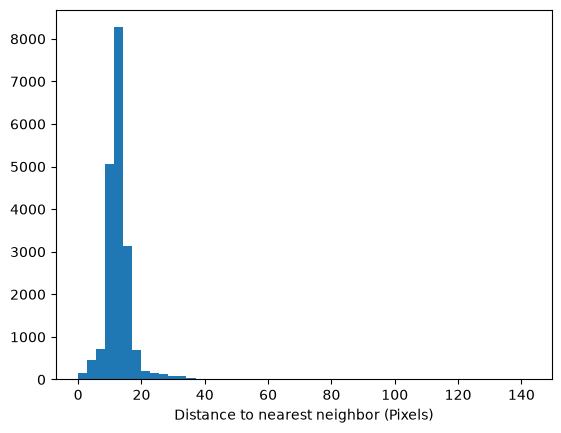

In [18]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

coords = adata.obsm['spatial']
# Find the distance to the single closest neighbor (k=2 because index 0 is self)
nn = NearestNeighbors(n_neighbors=2).fit(coords)
distances, _ = nn.kneighbors(coords)

plt.hist(distances[:, 1], bins=50)
plt.xlabel('Distance to nearest neighbor (Pixels)')
plt.show()

In [19]:
#del xenium_ad

## Co-localization

Here we'll be using a small test dataset of 3 control and 3 ICM samples for the test

We previously obtained co-localization probabilities for each cell type pair in each sample from cell boundaries overlap counts (**merfish_coloc_test.py**).

We have concatenated co-localization sample matrices of cell type x cell type.

In [20]:
#CTcolocalizationP=pd.read_csv('./CODEX_run45_CTcolocalizationP.csv', index_col=0)
#CTcolocalizationP=pd.read_csv('./CODEX_run45_CTcolocalizationP_radius40.csv', index_col=0)
#CTcolocalizationP=pd.read_csv('./CODEX_run45_CTcolocalizationP_radius200.csv', index_col=0)
CTcolocalizationP=pd.read_csv('../res_data/revision/CODEX/CODEX_run45_CTcolocalizationP_radius600_final.csv', index_col=0)

In [21]:
CTcolocalizationP.head()

,CD45+_hematopoietic_cells,Perivascular_myofibroblasts,Sinusoidal_endothelial_cells,Megakaryocytes,Erythroid_lineage,Myofibroblasts,Activated_MSCs_CAR_cells,Vascular_endothelial_cells,Pericytes,Spp1+_Sinusoidal_pericytes,Spp1+_Immune,Spp1+_Osteolineage_cells,sample
CD45+_hematopoietic_cells,0.106206,0.034607,0.040860,0.016758,0.047349,0.006858,0.020671,0.005312,0.004536,0.003915,0.020206,0.006059,run46_EV_1
Perivascular_myofibroblasts,0.034607,0.019854,0.017711,0.006833,0.017575,0.004065,0.008047,0.001564,0.001846,0.002171,0.007339,0.003577,run46_EV_1
Sinusoidal_endothelial_cells,0.040860,0.017711,0.019689,0.007401,0.017992,0.003190,0.007906,0.002426,0.002122,0.002370,0.009399,0.003531,run46_EV_1
Megakaryocytes,0.016758,0.006833,0.007401,0.002870,0.007734,0.001304,0.003222,0.000905,0.000800,0.000770,0.003455,0.001191,run46_EV_1
Erythroid_lineage,0.047349,0.017575,0.017992,0.007734,0.024540,0.003890,0.010846,0.001956,0.002038,0.001797,0.008967,0.003086,run46_EV_1


Same cell type interactions will be excluded later on, so we'll have a list of same cell type interaction pairs in order to subset the co-localization table we'll generate in the next step.

In [22]:
oneCTints=CTcolocalizationP.columns[range(len(CTcolocalizationP.columns)-1)]+'-'+CTcolocalizationP.columns[range(len(CTcolocalizationP.columns)-1)]

In [23]:
len(oneCTints)

12

In [24]:
cell_types=CTcolocalizationP.columns[0:len(CTcolocalizationP.columns)-1]
cell_types

Index(['CD45+_hematopoietic_cells', 'Perivascular_myofibroblasts',
       'Sinusoidal_endothelial_cells', 'Megakaryocytes', 'Erythroid_lineage',
       'Myofibroblasts', 'Activated_MSCs_CAR_cells',
       'Vascular_endothelial_cells', 'Pericytes', 'Spp1+_Sinusoidal_pericytes',
       'Spp1+_Immune', 'Spp1+_Osteolineage_cells'],
      dtype='object')

Then we will reshape the co-localization data into a matrix of cell type pairs x samples

The sum of the probabilities of every cell type pair in a sample must be = 1

In [25]:
colocPerSample=nichesphere.coloc.reshapeColoc(CTcoloc=CTcolocalizationP, complete=1)
colocPerSample.sum(axis=1)

run46_EV_1      1.0
run46_Thpo_2    1.0
dtype: float64

In [26]:
colocPerSample

,CD45+_hematopoietic_cells-CD45+_hematopoietic_cells,CD45+_hematopoietic_cells-Perivascular_myofibroblasts,CD45+_hematopoietic_cells-Sinusoidal_endothelial_cells,CD45+_hematopoietic_cells-Megakaryocytes,CD45+_hematopoietic_cells-Erythroid_lineage,CD45+_hematopoietic_cells-Myofibroblasts,CD45+_hematopoietic_cells-Activated_MSCs_CAR_cells,CD45+_hematopoietic_cells-Vascular_endothelial_cells,CD45+_hematopoietic_cells-Pericytes,CD45+_hematopoietic_cells-Spp1+_Sinusoidal_pericytes,...,Spp1+_Osteolineage_cells-Sinusoidal_endothelial_cells,Spp1+_Osteolineage_cells-Megakaryocytes,Spp1+_Osteolineage_cells-Erythroid_lineage,Spp1+_Osteolineage_cells-Myofibroblasts,Spp1+_Osteolineage_cells-Activated_MSCs_CAR_cells,Spp1+_Osteolineage_cells-Vascular_endothelial_cells,Spp1+_Osteolineage_cells-Pericytes,Spp1+_Osteolineage_cells-Spp1+_Sinusoidal_pericytes,Spp1+_Osteolineage_cells-Spp1+_Immune,Spp1+_Osteolineage_cells-Spp1+_Osteolineage_cells
run46_EV_1,0.106206,0.034607,0.040860,0.016758,0.047349,0.006858,0.020671,0.005312,0.004536,0.003915,...,0.003531,0.001191,0.003086,0.000587,0.001516,0.000329,0.000365,0.000572,0.001777,0.000948
run46_Thpo_2,0.042537,0.020963,0.017266,0.036217,0.012740,0.028155,0.023801,0.004929,0.001692,0.000557,...,0.002650,0.004758,0.002206,0.004785,0.002996,0.000842,0.000217,0.000274,0.000133,0.001806


In [27]:
#colocPerSample=pd.read_csv('./colocPerSample.csv', index_col=0)

In [28]:
#colocPerSample.sum(axis=1)

Conditions

To subset the samples, we will have this dataframe of sample names and conditions. In this case, condition can be inferred from the sample name

In [29]:
#pd.DataFrame(adata.obs.clusters_named.value_counts()).to_csv('./CODEX_run27-29_CT_counts_rev.csv')

In [30]:
adata.obs.clusters_named.value_counts()

clusters_named
CD45+_hematopoietic_cells       4296
Perivascular_myofibroblasts     3026
Megakaryocytes                  2257
Sinusoidal_endothelial_cells    2093
Erythroid_lineage               1938
Myofibroblasts                  1797
Activated_MSCs_CAR_cells        1686
Spp1+_Osteolineage_cells         753
Spp1+_Immune                     548
Vascular_endothelial_cells       420
Spp1+_Sinusoidal_pericytes       223
Pericytes                        208
Name: count, dtype: int64

In [31]:
#sampleTypesDF=merfish_obs[['sample', 'status']].drop_duplicates()
sampleTypesDF=adata.obs[['sample', 'condition']].drop_duplicates()
sampleTypesDF.reset_index(drop=True, inplace=True)
sampleTypesDF.columns=['sample', 'sampleType']
sampleTypesDF.index=sampleTypesDF['sample']
sampleTypesDF.head()

,sample,sampleType
sample,,
run46_EV_1,run46_EV_1,EV
run46_Thpo_2,run46_Thpo_2,Thpo


In [32]:
sampleTypesDF=sampleTypesDF.loc[colocPerSample.index]
sampleTypesDF

,sample,sampleType
run46_EV_1,run46_EV_1,EV
run46_Thpo_2,run46_Thpo_2,Thpo


In [33]:
sampleTypesDF.sampleType.unique()

['EV', 'Thpo']
Categories (2, object): ['EV', 'Thpo']

In this case, we do not have multiple samples from our two different conditions, so we will test differential co-localization by calculating O/E ratios of co-localization probabilities of cell type pairs in randomly generated doublets from our singlets data (background distribution) and comparing the O/E ratios we get from our data to this background distribution. 

First we will generate the background distribution from our singlets data. Differential co-localization will be significant if the co-localization probability for a cell type pair in one condition in the real data is among the 0.025 smallest or biggest values in the distribution (p=0.05).

In [34]:
#### Improve test: cell type pair specificity

In [35]:
# -> do 1000 times , get distribution of 1000 values per cell pair(?)

In [36]:
from joblib import Parallel, delayed
import time
from collections import Counter

In [37]:
def PIC_BGdoubletsOEratios_parallel(seed, adata, annot_col, target_pairs):
    # Initialize a local random generator with the specific seed
    random.seed(seed)
    # 1. Shuffle to randomize the order
    my_list=list(adata.obs[annot_col])
    random.shuffle(my_list)
    # 2. Pair them up and format into strings
    it = iter(my_list)
    observed_pairs = [f"{a}-{b}" for a, b in zip(it, it)]

    # 3. Calculate Observed Frequencies
    obs_counts = Counter(observed_pairs)
    total_gen = len(observed_pairs)
    
    # 4. Calculate Expected Frequencies
    # Expected = P(Item1) * P(Item2 | Item1) * Total Pairs
    item_counts = Counter(my_list)
    n = len(my_list)

    def calculate_ratio(pair_str):
        try:
            a, b = pair_str.split('-')
            # Probability of A then B
            p_a = item_counts[a] / n
            p_b = (item_counts[b] - (1 if a == b else 0)) / (n - 1)
            expected = p_a * p_b * total_gen
            
            observed = obs_counts.get(pair_str, 0)
            return observed / expected if expected > 0 else 0.0
        except:
            return 0.0

    # 5. Create the Pandas Series
    oe_ratios = pd.Series(
        {pair: calculate_ratio(pair) for pair in target_pairs},
        name="OE_Ratio"
    )
    
    #t=pd.Series(random_strings)
    return oe_ratios

In [38]:
#t = time.time()
#res=Parallel(n_jobs=10)(delayed(PIC_BGdoubletsOEratios_parallel)(seed=i, adata=adata[adata.obs.condition=='Thpo'], annot_col='clusters_named', target_pairs=colocPerSample.columns) for i in range(1000))
#print(time.time() - t)

In [39]:
#df = pd.concat(res, axis=1).T

In [40]:
#df=df.fillna(0)

In [41]:
#df

In [42]:
######################3

Then, we will compute the expected probability of each cell type pair to occur in each condition by multiplying cell type proportions from the single cell data.

In [43]:
#scCTpairsProbs_TPO=nichesphere.tl.getExpectedColocProbsFromSCs(sc_adata=adata, sample='Thpo', cell_types=cell_types, sc_data_sampleCol='condition', sc_adata_annotationCol='clusters_named')
#scCTpairsProbs_EV=nichesphere.tl.getExpectedColocProbsFromSCs(sc_adata=adata, sample='EV', cell_types=cell_types, sc_data_sampleCol='condition', sc_adata_annotationCol='clusters_named')


In [44]:
df_Thpo=pd.read_csv('run46_Thpo_2_600_testDistribution_df_final.csv', index_col=0)
df_EV=pd.read_csv('run46_EV_1_600_testDistribution_df_final.csv', index_col=0)
df_EV.head()

,CD45+_hematopoietic_cells-CD45+_hematopoietic_cells,CD45+_hematopoietic_cells-Perivascular_myofibroblasts,CD45+_hematopoietic_cells-Sinusoidal_endothelial_cells,CD45+_hematopoietic_cells-Megakaryocytes,CD45+_hematopoietic_cells-Erythroid_lineage,CD45+_hematopoietic_cells-Myofibroblasts,CD45+_hematopoietic_cells-Activated_MSCs_CAR_cells,CD45+_hematopoietic_cells-Vascular_endothelial_cells,CD45+_hematopoietic_cells-Pericytes,CD45+_hematopoietic_cells-Spp1+_Sinusoidal_pericytes,...,Spp1+_Osteolineage_cells-Sinusoidal_endothelial_cells,Spp1+_Osteolineage_cells-Megakaryocytes,Spp1+_Osteolineage_cells-Erythroid_lineage,Spp1+_Osteolineage_cells-Myofibroblasts,Spp1+_Osteolineage_cells-Activated_MSCs_CAR_cells,Spp1+_Osteolineage_cells-Vascular_endothelial_cells,Spp1+_Osteolineage_cells-Pericytes,Spp1+_Osteolineage_cells-Spp1+_Sinusoidal_pericytes,Spp1+_Osteolineage_cells-Spp1+_Immune,Spp1+_Osteolineage_cells-Spp1+_Osteolineage_cells
0,0.088530,0.040079,0.041959,0.015737,0.042415,0.006947,0.019119,0.004799,0.004366,0.005398,...,0.004371,0.001672,0.004457,0.000735,0.002001,0.000510,0.000462,0.000563,0.001973,0.000988
1,0.089126,0.040241,0.042099,0.015848,0.042686,0.006599,0.019409,0.004941,0.004195,0.005072,...,0.004354,0.001662,0.004430,0.000698,0.002029,0.000517,0.000448,0.000512,0.001954,0.000954
2,0.089186,0.039987,0.042064,0.015878,0.042484,0.007002,0.019401,0.004849,0.004446,0.005573,...,0.004323,0.001626,0.004375,0.000717,0.001995,0.000496,0.000467,0.000571,0.001944,0.000964
3,0.089111,0.039975,0.041871,0.016041,0.042362,0.006922,0.019135,0.004778,0.004243,0.005214,...,0.004448,0.001706,0.004486,0.000735,0.002058,0.000497,0.000454,0.000554,0.002065,0.000985
4,0.087665,0.039540,0.042203,0.015940,0.041957,0.006590,0.019132,0.004970,0.004354,0.005340,...,0.004570,0.001724,0.004524,0.000712,0.002056,0.000541,0.000477,0.000577,0.002044,0.001010


In [45]:
scCTpairsProbs_TPO=df_Thpo.mean()
scCTpairsProbs_EV=df_EV.mean()
scCTpairsProbs_EV

CD45+_hematopoietic_cells-CD45+_hematopoietic_cells       0.088434
CD45+_hematopoietic_cells-Perivascular_myofibroblasts     0.039879
CD45+_hematopoietic_cells-Sinusoidal_endothelial_cells    0.042044
CD45+_hematopoietic_cells-Megakaryocytes                  0.015953
CD45+_hematopoietic_cells-Erythroid_lineage               0.042176
                                                            ...   
Spp1+_Osteolineage_cells-Vascular_endothelial_cells       0.000507
Spp1+_Osteolineage_cells-Pericytes                        0.000465
Spp1+_Osteolineage_cells-Spp1+_Sinusoidal_pericytes       0.000571
Spp1+_Osteolineage_cells-Spp1+_Immune                     0.001987
Spp1+_Osteolineage_cells-Spp1+_Osteolineage_cells         0.000983
Length: 144, dtype: float64

Afterwards, we will calculate observed / expected ratios and log2 scale them with the function OvsE_coloc_test. We filter the same cell interactions as well. This function can also filter non significant values given a p-value (p). We will do this later to build the differential co-localization network

We can plot the log2(O/E) ratios in a heatmap and cluster the cells according to these scores.

In [46]:
from statsmodels.stats.multitest import multipletests

In [47]:
#nichesphere.coloc.OvsE_coloc_test_adjPval

In [48]:
## ADD p-value correction
def OvsE_coloc_test(observedColocProbs, expectedColocProbs, testDistribution_df, cell_types, oneCTinteractions, p=0.05, MTcorrection='fdr_bh'):
    """ Observed vs Expected log2 ratios filtered by p-value obtained from comparing them against a background distribution
    Parameters
    ----------
    observedColocProbs : pd.Series
        observed cell type pair co-localization probabilities in a sample/condition
    expectedColocProbs : pd.Series
        expected cell type pair co-localization probabilities in a sample/condition
    cell_types : list 
        list of cell types (sorted as in observedColocProbs)
    testDistribution : list
        distribution of log2 observed vs expected ratios obtained from random sampling pairs of single cells
        from scRNA data from the same sample/condition (obtained generally from function 'PIC_OEratios_BGdist')
        from the tl module
    oneCTinteractions : list
        list of single cell interactions (celltype-celltype)
    p : float (default: 0.05)
        values must have a p-value lower than this to be considered significant
    Returns
    -------
    OvsE_HMdf : pd.DataFrame
        cell types x cell types data frame of log2 observed/expected significant values (scores) for each cell cell interaction
    """
    eps=1e-9
    OvsE=(observedColocProbs+eps)/(expectedColocProbs+eps)
    OvsE_HM=np.log2(OvsE+ eps)
    pvals=pd.Series([scipy.stats.percentileofscore(np.log2(testDistribution_df[x]+ eps), OvsE_HM[x], kind='weak')/100 for x in OvsE_HM.index])
    #for i in pvals[pvals>0.5]:
    #    i=(1-i)
    pvals[pvals>0.5]=1-pvals[pvals>0.5]
    pvals=pvals*2
    pvals_corr=multipletests(pvals, alpha=0.05, method=MTcorrection, maxiter=1, is_sorted=False, returnsorted=False)[1]
    #OvsE_HM[(OvsE_HM>np.quantile(np.log2(testDistribution), p/2)) & (OvsE_HM<np.quantile(np.log2(testDistribution), 1-(p/2)))]=0
    #OvsE_HM[(pvals_corr>p/2) & (pvals_corr<1-(p/2))]=0

    statsDF=pd.DataFrame({'statistic':list(OvsE_HM), 'pvalue':list(pvals), 'adjusted_pvalue':list(pvals_corr)})
    statsDF.index=observedColocProbs.index
    
    OvsE_HM[(pvals_corr>p)]=0
    OvsE_HM[oneCTinteractions]=0
    
    OvsE_HMdf=pd.DataFrame(np.array(OvsE_HM).reshape(-1, len(cell_types)))
    OvsE_HMdf.columns=cell_types
    OvsE_HMdf.index=cell_types
    
    #statsDF.columns=['statistic', 'pvalue', 'adjusted_pvalue']
    return OvsE_HMdf,statsDF

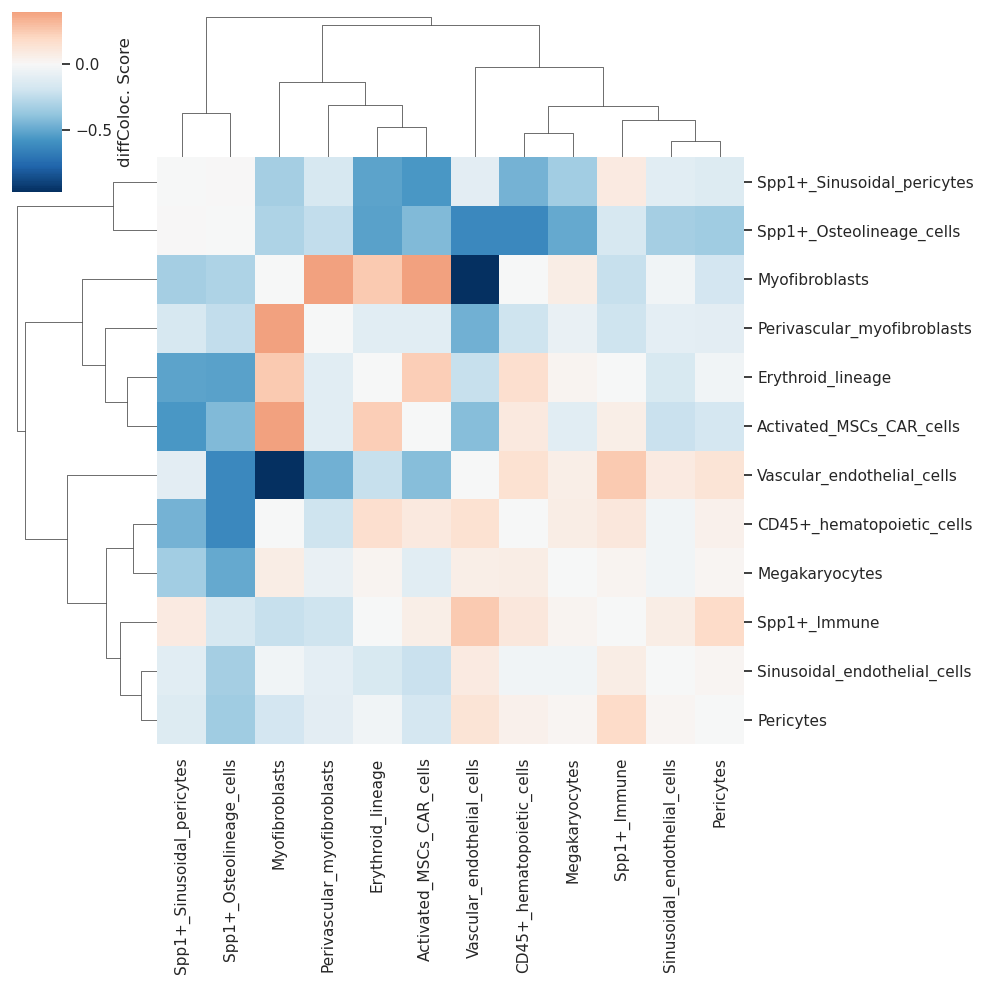

In [49]:
OvsE_EV_HMdf,statsEV=OvsE_coloc_test(observedColocProbs=colocPerSample.loc['run46_EV_1'], expectedColocProbs=scCTpairsProbs_EV, cell_types=cell_types, 
                              testDistribution_df=df_EV, oneCTinteractions=oneCTints, p=0.05)
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(OvsE_EV_HMdf, cmap='RdBu_r', center=0, method='ward', cbar_kws={'label': 'diffColoc. Score'})

In [50]:
statsEV.head(20)

,statistic,pvalue,adjusted_pvalue
CD45+_hematopoietic_cells-CD45+_hematopoietic_cells,0.264194,0.0,0.0
CD45+_hematopoietic_cells-Perivascular_myofibroblasts,-0.204555,0.0,0.0
CD45+_hematopoietic_cells-Sinusoidal_endothelial_cells,-0.041196,0.0,0.0
CD45+_hematopoietic_cells-Megakaryocytes,0.071028,0.0,0.0
CD45+_hematopoietic_cells-Erythroid_lineage,0.166916,0.0,0.0
CD45+_hematopoietic_cells-Myofibroblasts,-0.000905,0.0,0.0
CD45+_hematopoietic_cells-Activated_MSCs_CAR_cells,0.097195,0.0,0.0
CD45+_hematopoietic_cells-Vascular_endothelial_cells,0.146277,0.0,0.0
CD45+_hematopoietic_cells-Pericytes,0.045660,0.0,0.0
CD45+_hematopoietic_cells-Spp1+_Sinusoidal_pericytes,-0.465160,0.0,0.0


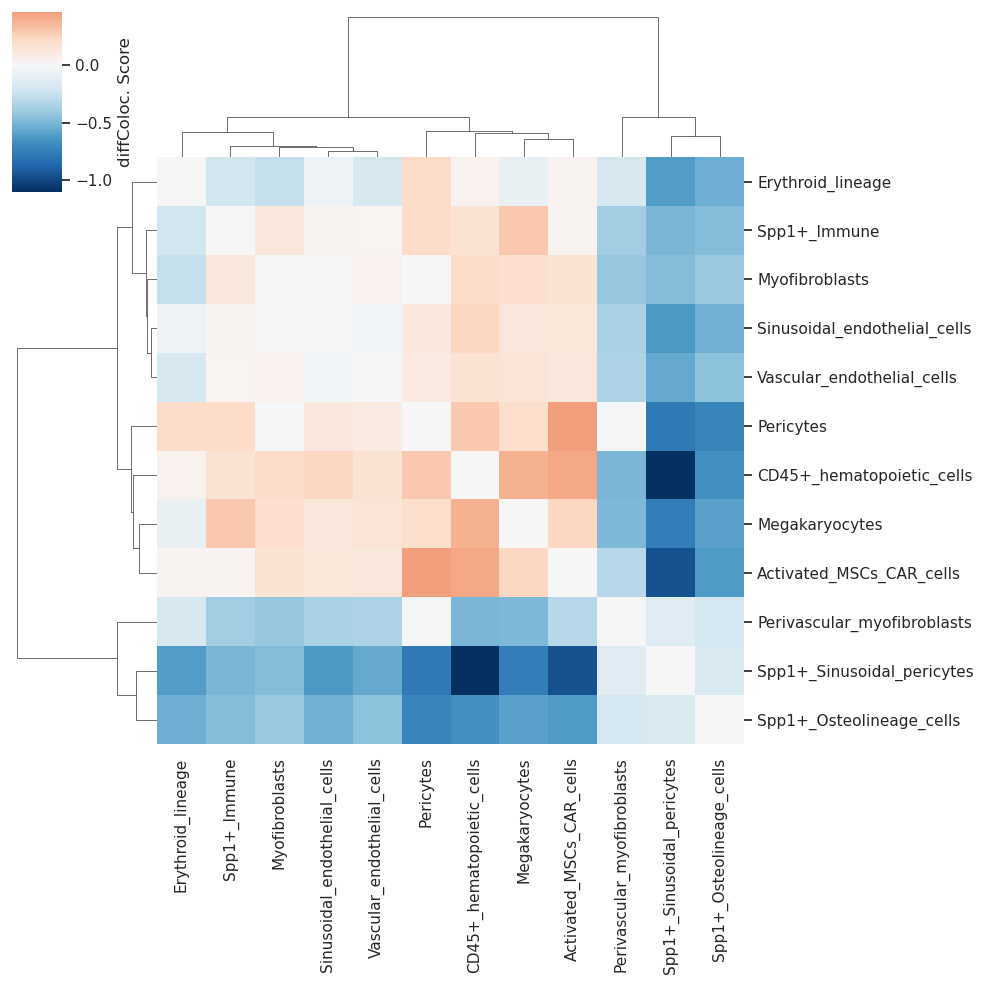

In [51]:
#OvsE_TPO_HMdf,stats=OvsE_coloc_test(observedColocProbs=colocPerSample.loc['run46_Thpo_2'], expectedColocProbs=scCTpairsProbs_TPO['count'], cell_types=cell_types, 
#                              testDistribution_df=df, oneCTinteractions=oneCTints, p=1)

OvsE_TPO_HMdf,statsTPO=OvsE_coloc_test(observedColocProbs=colocPerSample.loc['run46_Thpo_2'], expectedColocProbs=scCTpairsProbs_TPO, cell_types=cell_types, 
                              testDistribution_df=df_Thpo, oneCTinteractions=oneCTints, p=0.05)
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(OvsE_TPO_HMdf, cmap='RdBu_r', center=0, method='ward', cbar_kws={'label': 'diffColoc. Score'})

In [52]:
statsTPO.head(20)

,statistic,pvalue,adjusted_pvalue
CD45+_hematopoietic_cells-CD45+_hematopoietic_cells,0.537524,0.0,0.0
CD45+_hematopoietic_cells-Perivascular_myofibroblasts,-0.502709,0.0,0.0
CD45+_hematopoietic_cells-Sinusoidal_endothelial_cells,0.230906,0.0,0.0
CD45+_hematopoietic_cells-Megakaryocytes,0.386225,0.0,0.0
CD45+_hematopoietic_cells-Erythroid_lineage,0.048547,0.0,0.0
CD45+_hematopoietic_cells-Myofibroblasts,0.204791,0.0,0.0
CD45+_hematopoietic_cells-Activated_MSCs_CAR_cells,0.425978,0.0,0.0
CD45+_hematopoietic_cells-Vascular_endothelial_cells,0.158049,0.0,0.0
CD45+_hematopoietic_cells-Pericytes,0.297001,0.0,0.0
CD45+_hematopoietic_cells-Spp1+_Sinusoidal_pericytes,-1.099598,0.0,0.0


In [53]:
pair = colocPerSample.loc['run46_Thpo_2'].index[0] # Pick the first pair
print(f"Observed Log2 Ratio: {np.log2(colocPerSample.loc['run46_Thpo_2'][pair]/scCTpairsProbs_TPO[pair])}")
print(f"Background Min: {np.log2(df_Thpo[pair]).min()}")
print(f"Background Max: {np.log2(df_Thpo[pair]).max()}")

Observed Log2 Ratio: 0.5375239115308077
Background Min: -5.161006846395941
Background Max: -5.029798153671087


In [54]:
niches_dict={'1_': list(OvsE_TPO_HMdf.index)}
clist=['#4daf4a']

We will assign each niche a color to plot them later on (we haven't clustered yet, so we use the same color for all nodes)

**Differential co-localization network**

To build the differential co-localization network, we will get an adjacency matrix (adj) based on the euclidean distances among the distributions of significant differential co-localization scores for the different cell types

In [55]:
HMdist=pd.DataFrame(scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(OvsE_TPO_HMdf)), 
                    columns=OvsE_TPO_HMdf.columns, index=OvsE_TPO_HMdf.index)

HMsimm=1-HMdist/HMdist.max().max()
##Cell pairs with not significant differential co-localization get 0
HMsimm[OvsE_TPO_HMdf==0]=0

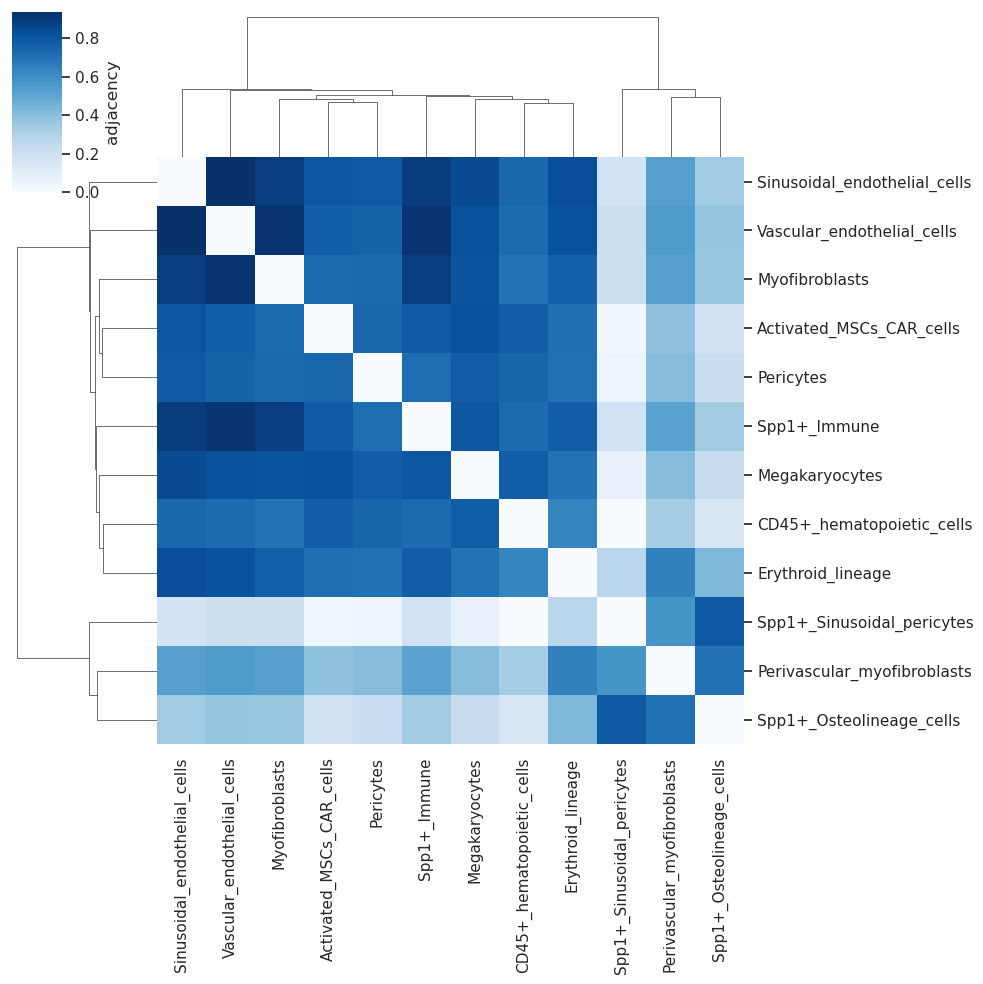

In [56]:
## Plot heatmap
sns.set(font_scale=1)
plot=sns.clustermap(HMsimm, cmap='Blues', method='ward', cbar_kws={'label': 'adjacency'})

Then the network is built just taking into account the differentially co-localized cell type pairs. The cell groups dictionary can be used here to visualize different cell groups in different colors.

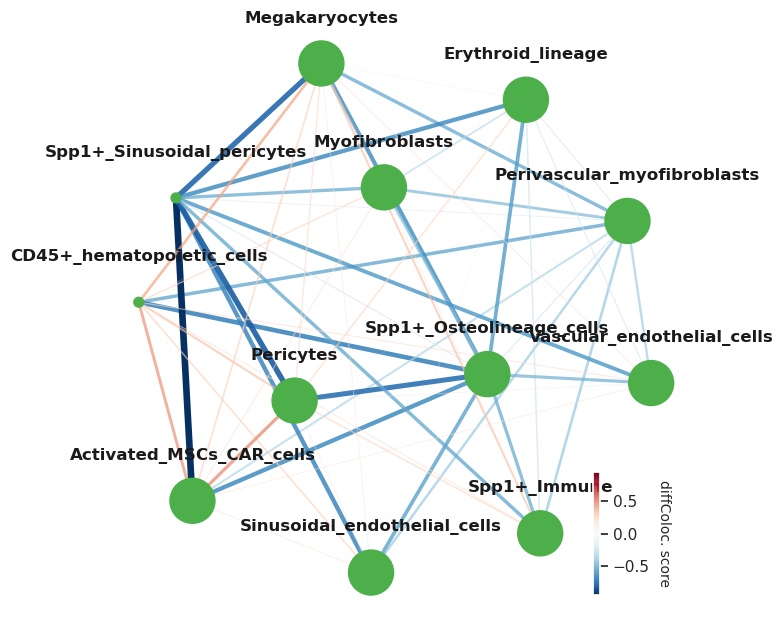

In [57]:
plt.rcParams['axes.facecolor'] = "None"
gCol=nichesphere.coloc.colocNW(x_diff=OvsE_TPO_HMdf, adj=HMsimm,cell_group=niches_dict, clist=clist, nodeSize='betweeness', layout='neato', edge_scale=5,thr=0)

In [58]:
## Unsigned network
gCol2=nx.from_pandas_adjacency(HMsimm, create_using=nx.Graph)

Now we'll do community detection using Louvain and make a communities dict

In [59]:
## Network clustering / clustering alternative
d=nx.algorithms.community.louvain_communities(gCol2,resolution=1.15, seed=1, weight='weight')
niches_dict=dict(enumerate([list(x) for x in d]))
niches_dict

{0: ['Vascular_endothelial_cells', 'Spp1+_Immune', 'Myofibroblasts'],
 1: ['Megakaryocytes',
  'CD45+_hematopoietic_cells',
  'Activated_MSCs_CAR_cells',
  'Pericytes',
  'Sinusoidal_endothelial_cells'],
 2: ['Erythroid_lineage',
  'Spp1+_Osteolineage_cells',
  'Perivascular_myofibroblasts',
  'Spp1+_Sinusoidal_pericytes']}

In [60]:
niche_names=['1_Spp1_immune_niche', '2_Fibrosis_interacting_core', '3_Osteo_niche']
niches_dict=dict(zip(niche_names,list(niches_dict.values()))) 


In [61]:
#Niches colors
cmap = plt.cm.get_cmap('tab10', 10)
clist=[mcolors.rgb2hex(cmap(i)[:3]) for i in [9]]
cmap = plt.cm.get_cmap('Set1', 9)
#clist=clist+[mcolors.rgb2hex(cmap(i)[:3]) for i in range(cmap.N)]
#clist=clist+[mcolors.rgb2hex(cmap(i)[:3]) for i in [7,2,3]]
clist=clist+[mcolors.rgb2hex(cmap(i)[:3]) for i in [7,2]]

niche_cols=pd.Series(clist, index=list(niches_dict.keys()))
niches_df=nichesphere.tl.cells_niche_colors(CTs=cell_types, niche_colors=niche_cols, niche_dict=niches_dict)

We will use the community-layout library function **CommunityLayout** to show the communities in a layout suited for this. This function is compatible with networkx (Hagberg et. al., 2008) community detection functions, which will be used internally as indicated by the parameters **community_algorithm** and **community_kwargs**

In [62]:
## Calculate community layout
cl=CommunityLayout(gCol2,
        community_compression = 0.35,
        layout_algorithm = nx.spring_layout,
        layout_kwargs = {"k":75, "iterations":1000},
        community_algorithm = nx.algorithms.community.louvain_communities,
        community_kwargs = {"resolution":1.15,  'seed':1, 'weight':'weight'})

Building meta-graph
Metagraph is a Graph with 3 nodes and 3 edges


100%|██████████| 3/3 [00:00<00:00, 111.44it/s]


In [63]:
# Load node positions
pos = np.load('./diffColocNW_node_positions_final.npy',allow_pickle='TRUE').item()

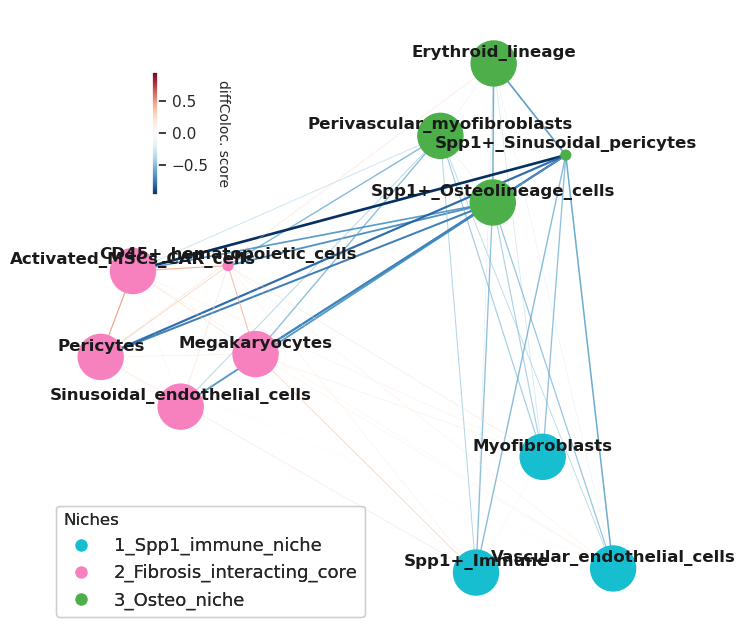

In [64]:
#pos=cl.full_positions
gCol=nichesphere.coloc.colocNW(x_diff=OvsE_TPO_HMdf, 
                               adj=HMsimm,
                               cell_group=niches_dict, 
                               clist=clist, 
                               nodeSize='betweeness', 
                               layout=None,                         #layout needs to be set to None if we provide node positions
                               lab_spacing=0.05, 
                               thr=0, 
                               #alpha=0.4, 
                               #fsize=(10,10), 
                               pos=pos,                             #node positions (from the CommunityLayout function)
                               edge_scale=2,                        #edge width
                               legend_ax=[0.05, 0.7, 0.15, 0.2]
                              )    #legend position
#Legend
legend_elements1=[plt.Line2D([0], [0], marker="o" ,color='w', markerfacecolor=clist[i], lw=4, 
                             label=list(niches_dict.keys())[i], ms=10) for i in range(len(list(niches_dict.keys())))]
plt.gca().add_artist(plt.legend(handles=legend_elements1,loc='lower left', fontsize=13, title='Niches', 
                                alignment='left'))
plt.savefig('./figures/revision_PIC/diffColocNW_CODEX_final.pdf')

In [65]:
## Save node positions
np.save('./diffColocNW_node_positions_final.npy', pos) 

In [66]:
#pos=nx.drawing.nx_agraph.graphviz_layout(gCol2,prog='neato')

In [67]:
nichesphere.tl.assign_properties(gCol, 
                                 communities=cl.communities(), 
                                 colors=clist, 
                                 pos=pos, 
                                 simmilarity_weights=True, 
                                 node_coord_sf=100,
                                 g_unsigned=gCol2)

In [68]:
import gravis as gv
gv.d3(gCol, edge_size_data_source='weight_abs', zoom_factor=0.35,  layout_algorithm_active=False)

We can then calculate some network statistics with the networkX package [ref] functions:

In [69]:
t0=pd.DataFrame({'betweenness':[nx.betweenness_centrality(gCol)[x] for x in list(gCol.nodes)], 
                 'degree':[nx.degree_centrality(gCol)[x] for x in list(gCol.nodes)], 'pagerank':[nx.pagerank(gCol, weight=None)[x] for x in list(gCol.nodes)]})
#t0=pd.DataFrame({'betweenness':[nx.betweenness_centrality(gCol)[x] for x in list(gCol.nodes)], 
#                 'degree':[nx.degree_centrality(gCol)[x] for x in list(gCol.nodes)], 'pagerank':[nx.pagerank(gCol, max_iter=1000000)[x] for x in list(gCol.nodes)]})
t0.index=list(gCol.nodes)

In [70]:
t0.head()

,betweenness,degree,pagerank
CD45+_hematopoietic_cells,0.000000,0.909091,0.077756
Perivascular_myofibroblasts,0.001818,1.000000,0.084449
Sinusoidal_endothelial_cells,0.001818,1.000000,0.084449
Megakaryocytes,0.001818,1.000000,0.084449
Erythroid_lineage,0.001818,1.000000,0.084449


And visualize them

In [71]:
## Positive edges stats
G_pos=gCol.copy()
to_remove=[(a,b) for a, b, attrs in G_pos.edges(data=True) if attrs["weight"] <= 0]
G_pos.remove_edges_from(to_remove)

t1=pd.DataFrame({'degree':[nx.degree_centrality(G_pos)[x] for x in list(G_pos.nodes)]})
t1.index=list(G_pos.nodes)

In [72]:
t3=pd.DataFrame({'betweenness_pos':[nx.betweenness_centrality(G_pos)[x] for x in list(G_pos.nodes)], 
                 'pagerank_pos':[nx.pagerank(G_pos)[x] for x in list(G_pos.nodes)]})
t3.index=list(G_pos.nodes)

In [73]:
## Negative edges stats
G_neg=gCol.copy()
to_remove=[(a,b) for a, b, attrs in G_neg.edges(data=True) if attrs["weight"] >= 0]
G_neg.remove_edges_from(to_remove)

t2=pd.DataFrame({'degree':[nx.degree_centrality(G_neg)[x] for x in list(G_neg.nodes)]})
t2.index=list(G_neg.nodes)

In [74]:
t4=pd.DataFrame({'betweenness_neg':[nx.betweenness_centrality(G_neg)[x] for x in list(G_neg.nodes)], 
                 'pagerank_neg':[nx.pagerank(G_neg)[x] for x in list(G_neg.nodes)]})
t4.index=list(G_neg.nodes)

In [75]:
t0.sort_values('betweenness', ascending=False).head()

,betweenness,degree,pagerank
Perivascular_myofibroblasts,0.001818,1.0,0.084449
Sinusoidal_endothelial_cells,0.001818,1.0,0.084449
Megakaryocytes,0.001818,1.0,0.084449
Erythroid_lineage,0.001818,1.0,0.084449
Pericytes,0.001818,1.0,0.084449


In [76]:
### new
#t0['betweenness']=t3.betweenness_pos-t4.betweenness_neg
#t0['pagerank']=t3.pagerank_pos-t4.pagerank_neg

### new
t0['betweenness']=np.log2((1e-10+t3.betweenness_pos)/(1e-10+t4.betweenness_neg))
t0['pagerank']=np.log2((1e-10+t3.pagerank_pos)/(1e-10+t4.pagerank_neg))

In [77]:
## unsigned
#t0['betweenness']=[nx.betweenness_centrality(gCol2)[x] for x in list(gCol2.nodes)]
#t0['pagerank']=[nx.pagerank(gCol2)[x] for x in list(gCol2.nodes)]

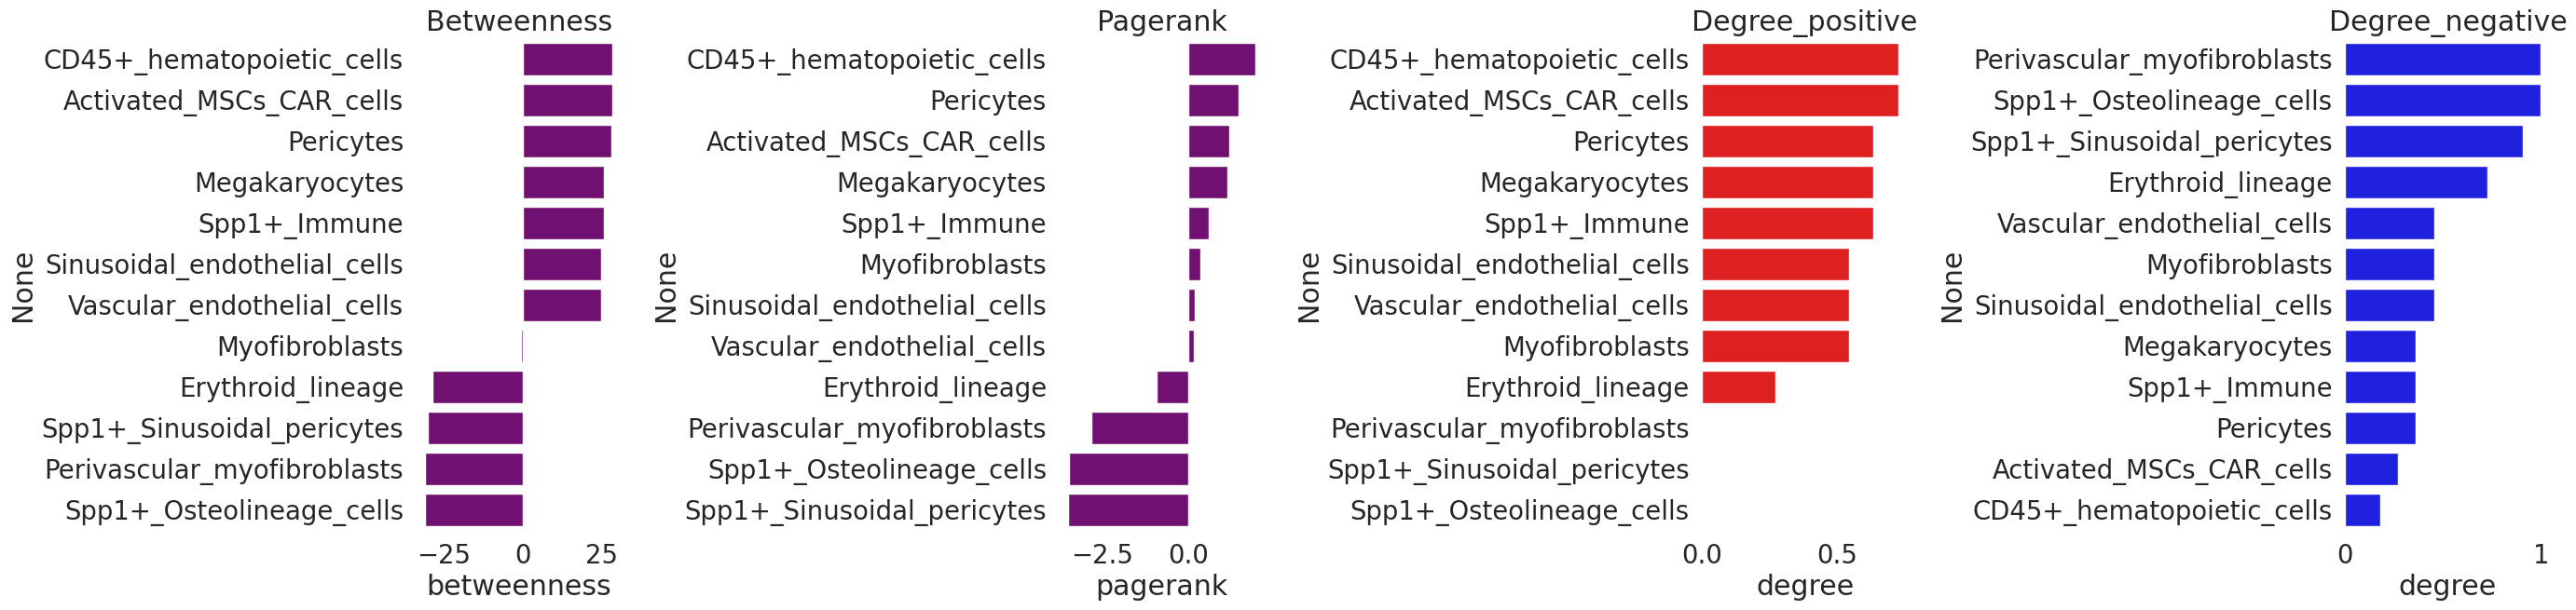

In [82]:
#fig, axes = plt.subplots(1, 3, figsize=(21, 7))
sns.set(font_scale=1.8)
plt.rcParams['axes.facecolor'] = "None"
fig, axes = plt.subplots(1, 4, figsize=(28, 7))
#sns.barplot(ax=axes[0], y=t1.sort_values('pagerank', ascending=False).index, x='pagerank', data=t1.sort_values('pagerank', ascending=False), color='red')
#axes[0].set_title('Pagerank')
sns.barplot(ax=axes[0], y=t0.sort_values('betweenness', ascending=False).index, x='betweenness', data=t0.sort_values('betweenness', ascending=False), color='purple')
axes[0].set_title('Betweenness')
sns.barplot(ax=axes[1], y=t0.sort_values('pagerank', ascending=False).index, x='pagerank', data=t0.sort_values('pagerank', ascending=False), color='purple')
axes[1].set_title('Pagerank')
sns.barplot(ax=axes[2], y=t1.sort_values('degree', ascending=False).index, x='degree', data=t1.sort_values('degree', ascending=False), color='red')
axes[2].set_title('Degree_positive')
sns.barplot(ax=axes[3], y=t2.sort_values('degree', ascending=False).index, x='degree', data=t2.sort_values('degree', ascending=False), color='blue')
axes[3].set_title('Degree_negative')

plt.tight_layout()

plt.savefig('./figures/revision_PIC/diffColocNW_stats_CODEX_new.pdf', bbox_inches='tight')
#plt.savefig('./figures/revision_PIC/diffColocNW_stats_CODEX_unsigned.pdf', bbox_inches='tight')

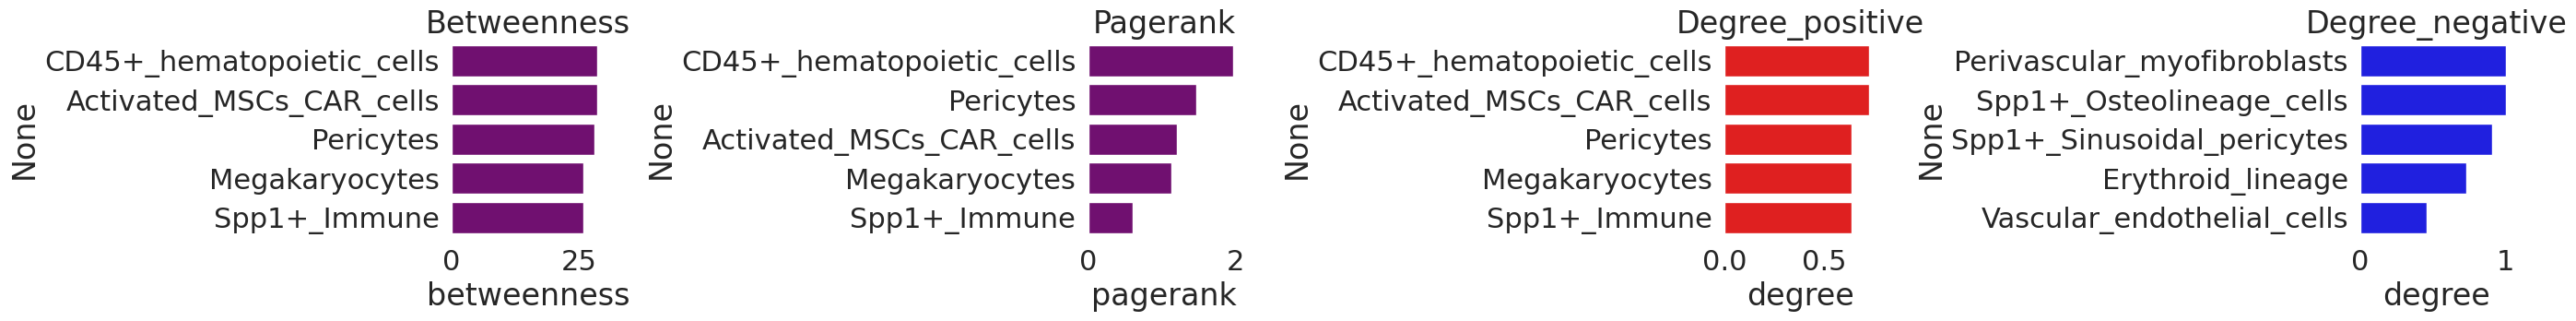

In [79]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig, axes = plt.subplots(1, 4, figsize=(28, 4))
#sns.barplot(ax=axes[0], y=t1.sort_values('pagerank', ascending=False).index, x='pagerank', data=t1.sort_values('pagerank', ascending=False), color='red')
#axes[0].set_title('Pagerank')
sns.barplot(ax=axes[0], y=t0.sort_values('betweenness', ascending=False).index[0:5], x='betweenness', data=t0.sort_values('betweenness', ascending=False)[0:5], color='purple')
axes[0].set_title('Betweenness')
sns.barplot(ax=axes[1], y=t0.sort_values('pagerank', ascending=False).index[0:5], x='pagerank', data=t0.sort_values('pagerank', ascending=False)[0:5], color='purple')
axes[1].set_title('Pagerank')
sns.barplot(ax=axes[2], y=t1.sort_values('degree', ascending=False).index[0:5], x='degree', data=t1.sort_values('degree', ascending=False)[0:5], color='red')
axes[2].set_title('Degree_positive')
sns.barplot(ax=axes[3], y=t2.sort_values('degree', ascending=False).index[0:5], x='degree', data=t2.sort_values('degree', ascending=False)[0:5], color='blue')
axes[3].set_title('Degree_negative')
#sns.barplot(ax=axes[2], y=t1.sort_values('betweenness', ascending=False).index, x='betweenness', data=t1.sort_values('betweenness', ascending=False), color='red')
#axes[2].set_title('Betweenness')
fig.tight_layout()
#plt.savefig('../figures/diffColocNW_stats_top5_updt.pdf', bbox_inches='tight')